# SASHIMI-SI: usage walkthrough

## Goal
Explore velocity-dependent interactions, evolve matched CDM/SIDM populations and inspect collapse and profile outputs.

Run **Restart Kernel and Run All**. Every code cell is required, including the checks. These small grids teach the API; they are not converged predictions or a replacement for scientific regression tests.

## Setup
Use Python 3.12 in a clean virtual environment, from this repository's `itamae-migration` checkout:
```sh
python -m venv .venv
source .venv/bin/activate
python -m pip install --upgrade pip
python -m pip install "sashimi-itamae @ git+https://github.com/gomeshun/itamae.git@94a1bc54a02fc698204cf20e7c41b8e57df3e614"
python -m pip install . numpy scipy matplotlib astropy colossus h5py numexpr tqdm nbformat nbclient ipykernel
```
Open this notebook with the `python3` kernel from that environment. ITAMAE means this project's GitHub package; do not substitute an unrelated package with the same PyPI name. No data download is performed by notebook cells.


In [1]:
import sys, tempfile
from pathlib import Path
from importlib.metadata import version
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from itamae.provenance import source_revision
import itamae, sashimi_si
packages = [("sashimi-itamae", "itamae", itamae), ("sashimi-si", "sashimi-si", sashimi_si)]
display({distribution: {'version': version(distribution), 'source_revision': source_revision(component, module_file=module.__file__)} for distribution, component, module in packages})
print(sys.version)
rng = np.random.default_rng(20260907)
workspace = tempfile.TemporaryDirectory(prefix="sashimi-si-walkthrough-")
work = Path(workspace.name)

{'sashimi-itamae': {'version': '0.2.0rc1',
  'source_revision': 'dfa083d0d46181c376947ac7b2da829facaf2e8b'},
 'sashimi-si': {'version': '0.2.0rc1',
  'source_revision': '8e5df165c809177ad9ed75019b9e7dcac703c347'}}

3.11.15 (main, Mar  3 2026, 14:59:53) [Clang 21.1.4 ]


## Cross section
Cross-section parameters are cm²/g and velocities are km/s. These are model inputs, not an inferred constraint.

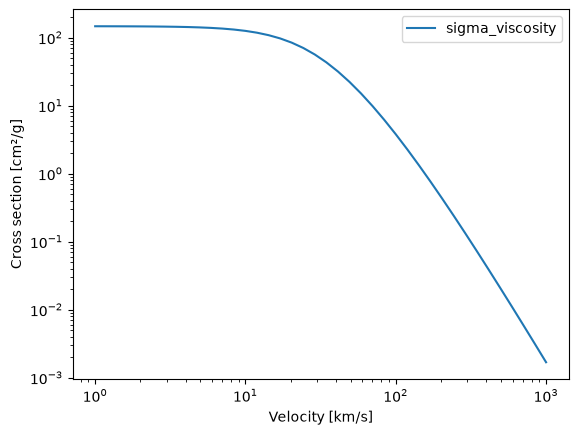

In [2]:
from sashimi_si import SIDM_cross_section
from sashimi_si import SubhaloProperties
physical = dict(sigma0_m=147.1, w=24.33)
velocity = np.geomspace(1, 1000, 40)
cross = SIDM_cross_section()
for name in ["sigma_viscosity"]:
    values = getattr(cross, name)(physical["sigma0_m"], physical["w"], velocity)
    assert np.all(np.isfinite(values))
    plt.loglog(velocity, values, label=name)
plt.legend(); plt.xlabel("Velocity [km/s]"); plt.ylabel("Cross section [cm²/g]"); plt.show()

## Matched CDM and SIDM catalogue views
The two views share accretion nodes but apply different structural and survival results. SI currently uses the same physical prescription for its legacy and consistent mode labels.

In [3]:
parameters = dict(M0=1e10, redshift=0., dz=.5, zmax=1., N_ma=4, sigmalogc=.128, N_herm=2, logmamin=5., logmamax=7., N_hermNa=2, Na_model=3, ct_th=0., method='pert2_shanks')
display(parameters)
model = SubhaloProperties(**physical)
catalogs = model.subhalo_catalogs_calc(**parameters)
catalog = catalogs["sidm"]
cdm = catalogs["cdm_reference"]
np.testing.assert_array_equal(catalog.columns["m200_acc"], cdm.columns["m200_acc"])
print("CDM / SIDM counts:", cdm.weight_final.sum(), catalog.weight_final.sum())

{'M0': 10000000000.0,
 'redshift': 0.0,
 'dz': 0.5,
 'zmax': 1.0,
 'N_ma': 4,
 'sigmalogc': 0.128,
 'N_herm': 2,
 'logmamin': 5.0,
 'logmamax': 7.0,
 'N_hermNa': 2,
 'Na_model': 3,
 'ct_th': 0.0,
 'method': 'pert2_shanks'}

CDM / SIDM counts: 289.7645066121662 289.7645066121662


## Inspect the catalogue contract
Rows are quadrature nodes, not individual satellites. `weight_final` combines the stored population and survival factors. Inspect the metadata before comparing physics modes or converting units; column names alone do not establish a unit convention.

In [4]:
from itamae.types import WeightedSubhaloCatalog
print("nodes:", catalog.shape, "expected surviving count:", float(catalog.weight_final.sum()))
print("columns:", sorted(catalog.columns))
print("weight factors:", sorted(catalog.weights))
display(catalog.metadata)
assert np.all(np.isfinite(catalog.weight_final))
assert np.all(catalog.weight_final >= 0)
assert catalog.weight_final.sum() > 0

nodes: (16,) expected surviving count: 289.7645066121662
columns: ['c_t_cdm', 'collapse_time_ratio', 'm200_acc', 'm_bound', 'r_c_sidm', 'r_c_sidm_acc', 'r_max_cdm', 'r_max_cdm_acc', 'r_max_sidm', 'r_max_sidm_acc', 'r_s_cdm', 'r_s_cdm_acc', 'r_s_sidm', 'r_s_sidm_acc', 'rho_s_cdm', 'rho_s_cdm_acc', 'rho_s_sidm', 'rho_s_sidm_acc', 'survive_cdm', 'survive_sidm', 'v_max_cdm', 'v_max_cdm_acc', 'v_max_sidm', 'v_max_sidm_acc', 'valid_accretion', 'z_acc']
weight factors: ['weight_base', 'weight_concentration', 'weight_survival']


mappingproxy({'schema_version': '1.0',
              'model_identifier': 'sashimi-si:sidm:v2',
              'backend_identifier': 'array=numpy;cosmology=native-flatlcdm:Om=0.315:h=0.674;units=native-units:1.0',
              'state': 'sidm',
              'physical_parameters': {'sigma0_m_cm2_g': 147.1,
               'w_km_s': 24.33,
               'beta': 4,
               'collapse_time_threshold': 1.1},
              'calculation_parameters': {'M0': 10000000000.0,
               'redshift': 0.0,
               'dz': 0.5,
               'zmax': 1.0,
               'N_ma': 4,
               'sigmalogc': 0.128,
               'N_herm': 2,
               'logmamin': 5.0,
               'logmamax': 7.0,
               'N_hermNa': 2,
               'Na_model': 3,
               'ct_th': 0.0,
               'M0_at_redshift': False,
               'method': 'pert2_shanks',
               'solver_options': {}},
              'cosmology_parameters': {'omega_m0': 0.315,
               'h': 0

## Select a population and plot its weighted mass function
A histogram sums expected counts, then division by the logarithmic bin width gives dN/dln M. Changing the mass range changes the population included; this is not a convergence test.

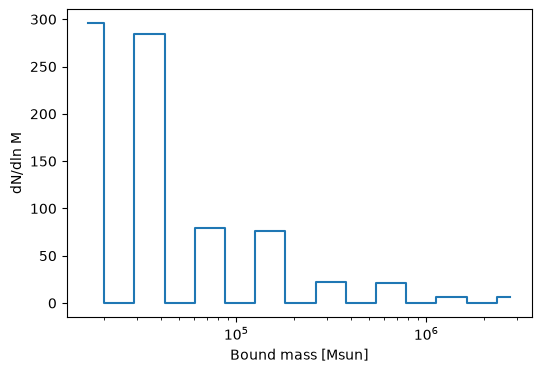

weighted bound mass: 29438698.040834114


In [5]:
mass = np.asarray(catalog.columns["m_bound"])
positive = (mass > 0) & (catalog.weight_final > 0)
selected = catalog.select(positive)
edges = np.geomspace(mass[positive].min()*0.99, mass[positive].max()*1.01, 16)
counts, edges = selected.weighted_histogram("m_bound", bins=edges)
np.testing.assert_allclose(counts.sum(), selected.weight_final.sum())
fig, ax = plt.subplots(figsize=(6, 4))
ax.step(np.sqrt(edges[:-1]*edges[1:]), counts/np.diff(np.log(edges)), where="mid")
ax.set(xscale="log", xlabel="Bound mass [Msun]", ylabel="dN/dln M")
plt.show()
print("weighted bound mass:", selected.weighted_sum(selected.columns["m_bound"]))

## Save and reload without pickle
NPZ retains the catalogue's columns, factorized weights and metadata. The round-trip checks make this notebook useful as a migration smoke test.

In [6]:
path = work / "catalog.npz"
catalog.to_npz(path)
restored = WeightedSubhaloCatalog.from_npz(path)
for name in catalog.columns:
    np.testing.assert_array_equal(restored.columns[name], catalog.columns[name])
np.testing.assert_array_equal(restored.weight_final, catalog.weight_final)
assert restored.metadata == catalog.metadata
print("NPZ round trip passed")

NPZ round trip passed


## Collapse diagnostic and structure
A collapse-time ratio above one selects the model’s collapsed population. This is a model diagnostic. Structural quantities below retain their catalogue units, reported in metadata.

weighted collapsed fraction: 0.03501110179414719


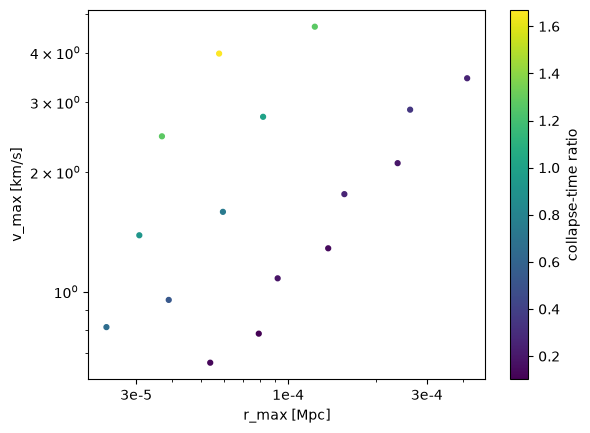

In [7]:
ratio = catalog.columns["collapse_time_ratio"]
collapsed = catalog.select(ratio > 1)
print("weighted collapsed fraction:", collapsed.weight_final.sum()/catalog.weight_final.sum())
valid = (catalog.weight_final > 0) & (catalog.columns["r_max_sidm"] > 0) & (catalog.columns["v_max_sidm"] > 0)
plt.scatter(catalog.columns["r_max_sidm"][valid], catalog.columns["v_max_sidm"][valid], c=ratio[valid], s=12)
plt.xscale("log"); plt.yscale("log"); plt.xlabel("r_max [Mpc]"); plt.ylabel("v_max [km/s]")
plt.gca().set_xticks([3e-5, 1e-4, 3e-4], labels=["3e-5", "1e-4", "3e-4"])
plt.gca().xaxis.set_minor_formatter(plt.NullFormatter())
plt.colorbar(label="collapse-time ratio"); plt.show()

## Coverage and next steps

| Area | Runnable example |
|---|---|
| Interaction | Total and viscosity cross section |
| Population | Matched CDM/SIDM views |
| Catalogue | Weights, selection, export |
| SIDM structure | Collapse fraction and r_max/v_max |

See `itamae_migration_demo.ipynb` for detailed legacy-array parity and larger comparison plots. Analytic interpolation routines may emit numerical warnings from discarded intermediate expressions; warnings are deliberately not globally suppressed here.

When a public feature is added or migrated, update this table, its runnable example and its checks in the same PR. Existing migration demos remain the detailed numerical comparison reference; passing this walkthrough does not close their separate regeneration work.

In [8]:
workspace.cleanup()
print("All walkthrough checks passed")

All walkthrough checks passed
